In [ ]:
import os
import numpy as np
from PIL import Image
from tqdm import tqdm

INPUT_DIR = r"D:\cells\А549\48"
OUTPUT_DIR = r"D:\cells\A549_png\48"
CONVERT_TO_GRAYSCALE = True
NORMALIZE_16BIT = True

os.makedirs(OUTPUT_DIR, exist_ok=True)

def normalize_to_8bit(img_array):

    img_array = img_array.astype(np.float32)

    min_val = np.min(img_array)
    max_val = np.max(img_array)

    if max_val - min_val == 0:
        return np.zeros_like(img_array, dtype=np.uint8)

    img_array = (img_array - min_val) / (max_val - min_val)
    img_array = (img_array * 255).clip(0, 255)

    return img_array.astype(np.uint8)

tiff_files = [f for f in os.listdir(INPUT_DIR) if f.lower().endswith((".tif", ".tiff"))]

print(f"Найдено файлов: {len(tiff_files)}")

for filename in tqdm(tiff_files):
    input_path = os.path.join(INPUT_DIR, filename)
    output_name = os.path.splitext(filename)[0] + ".png"
    output_path = os.path.join(OUTPUT_DIR, output_name)

    with Image.open(input_path) as img:

        img_array = np.array(img)

        if CONVERT_TO_GRAYSCALE and len(img_array.shape) == 3:
            img_array = np.mean(img_array, axis=2)

        if NORMALIZE_16BIT and img_array.dtype != np.uint8:
            img_array = normalize_to_8bit(img_array)

        img_out = Image.fromarray(img_array)
        img_out.save(output_path, format="PNG")

print("Готово.")

Найдено файлов: 226


100%|██████████| 226/226 [15:42<00:00,  4.17s/it]

Готово.


In [1]:
from pathlib import Path
import random
import shutil

SRC_ROOT = Path(r"A549_png")   
DST_ROOT = Path(r"dataset")  
CLASSES = ["24", "48", "72", "healthy"]

SEED = 42
TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15
TEST_FRAC  = 0.15

MIN_VAL_PER_CLASS = 10
MIN_TEST_PER_CLASS = 10


random.seed(SEED)

def list_pngs(class_dir: Path):
    return sorted([p for p in class_dir.rglob("*.png") if p.is_file()])

def ensure_dirs():
    for split in ["train", "val", "test"]:
        for c in CLASSES:
            (DST_ROOT / split / c).mkdir(parents=True, exist_ok=True)

def split_counts(n: int):
    n_val = max(int(round(n * VAL_FRAC)), MIN_VAL_PER_CLASS)
    n_test = max(int(round(n * TEST_FRAC)), MIN_TEST_PER_CLASS)

    if n_val + n_test >= n:
        n_val = min(n_val, n - 2)
        n_test = min(n_test, n - 1 - n_val)

    n_train = n - n_val - n_test
    return n_train, n_val, n_test

def copy_files(files, out_dir: Path):
    out_dir.mkdir(parents=True, exist_ok=True)
    for src in files:
        dst = out_dir / src.name
        if not dst.exists():
            shutil.copy2(src, dst)

missing = [c for c in CLASSES if not (SRC_ROOT / c).is_dir()]
if missing:
    raise SystemExit(f"Не найдены папки классов в {SRC_ROOT}: {missing}")

ensure_dirs()

summary = {}

for c in CLASSES:
    files = list_pngs(SRC_ROOT / c)
    n = len(files)
    if n == 0:
        raise SystemExit(f"Класс {c} пустой")

    random.shuffle(files)
    n_train, n_val, n_test = split_counts(n)

    val_files = files[:n_val]
    test_files = files[n_val:n_val + n_test]
    train_files = files[n_val + n_test:]

    copy_files(train_files, DST_ROOT / "train" / c)
    copy_files(val_files,   DST_ROOT / "val"   / c)
    copy_files(test_files,  DST_ROOT / "test"  / c)

    summary[c] = {"train": len(train_files), "val": len(val_files), "test": len(test_files), "total": n}

print(f"SRC_ROOT = {SRC_ROOT.resolve()}")
print(f"DST_ROOT = {DST_ROOT.resolve()}\n")

print("Распределение по классам:")
tot_train = tot_val = tot_test = tot_all = 0
for c in CLASSES:
    s = summary[c]
    print(f"  {c:>7}: train={s['train']:>3}  val={s['val']:>3}  test={s['test']:>3}  total={s['total']}")
    tot_train += s["train"]
    tot_val   += s["val"]
    tot_test  += s["test"]
    tot_all   += s["total"]

print("\nИТОГО:")
print(f"  train={tot_train}  val={tot_val}  test={tot_test}  total={tot_all}")

SRC_ROOT = D:\cells\A549_png
DST_ROOT = D:\cells\dataset

Распределение по классам:
       24: train=154  val= 33  test= 33  total=220
       48: train=158  val= 34  test= 34  total=226
       72: train= 52  val= 11  test= 11  total=74
  healthy: train= 41  val= 10  test= 10  total=61

ИТОГО:
  train=405  val=88  test=88  total=581


In [2]:
import tensorflow as tf
from pathlib import Path

DATASET_ROOT = Path("dataset")

IMG_SIZE = (512, 512)
BATCH_SIZE = 8
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_ROOT / "train",
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_ROOT / "val",
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_ROOT / "test",
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Class names:", train_ds.class_names)

Found 405 files belonging to 4 classes.
Found 88 files belonging to 4 classes.
Found 88 files belonging to 4 classes.
Class names: ['24', '48', '72', 'healthy']


In [3]:
import tensorflow as tf
import numpy as np

AUTOTUNE = tf.data.AUTOTUNE

rescale = tf.keras.layers.Rescaling(1./255)

augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.05), 
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomContrast(0.10),
], name="augment")

train_ds_fast = train_ds.cache().shuffle(512).prefetch(AUTOTUNE)
val_ds_fast   = val_ds.cache().prefetch(AUTOTUNE)
test_ds_fast  = test_ds.cache().prefetch(AUTOTUNE)

In [4]:
from collections import Counter

y_train = []
for _, labels in train_ds:
    y_train.extend(labels.numpy().tolist())

counts = Counter(y_train)
num_classes = len(train_ds.class_names)
total = len(y_train)

class_weight = {cls: total / (num_classes * cnt) for cls, cnt in counts.items()}

print("class_names:", train_ds.class_names)
print("train class counts:", dict(counts))
print("class_weight:", class_weight)

class_names: ['24', '48', '72', 'healthy']
train class counts: {2: 52, 1: 158, 0: 154, 3: 41}
class_weight: {2: 1.9471153846153846, 1: 0.6408227848101266, 0: 0.6574675324675324, 3: 2.4695121951219514}


In [17]:
for images, labels in train_ds.take(1):
    print("Batch images:", images.shape, images.dtype)
    print("Batch labels:", labels[:10].numpy())

Batch images: (8, 512, 512, 3) <dtype: 'float32'>
Batch labels: [1 0 0 0 0 0 1 0]


In [ ]:
import tensorflow as tf
import numpy as np
from collections import Counter

AUTOTUNE = tf.data.AUTOTUNE

train_ds_fast = train_ds.cache().shuffle(512).prefetch(AUTOTUNE)
val_ds_fast   = val_ds.cache().prefetch(AUTOTUNE)
test_ds_fast  = test_ds.cache().prefetch(AUTOTUNE)

y_train = []
for _, labels in train_ds:
    y_train.extend(labels.numpy().tolist())

counts = Counter(y_train)
num_classes = len(train_ds.class_names)
total = len(y_train)
class_weight = {cls: total / (num_classes * cnt) for cls, cnt in counts.items()}

print("class_names:", train_ds.class_names)
print("train class counts:", dict(counts))
print("class_weight:", class_weight)

class_names: ['24', '48', '72', 'healthy']
train class counts: {0: 154, 2: 52, 1: 158, 3: 41}
class_weight: {0: 0.6574675324675324, 2: 1.9471153846153846, 1: 0.6408227848101266, 3: 2.4695121951219514}


In [ ]:

import tensorflow as tf
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

IMG_SIZE = 512
NUM_CLASSES = len(train_ds.class_names)

augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomContrast(0.10),
], name="augment")

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = augment(inputs)
x = tf.keras.layers.Lambda(preprocess_input, name="preprocess")(x)

base = tf.keras.applications.EfficientNetV2S(
    include_top=False,
    weights="imagenet",
    input_tensor=x
)
base.trainable = False  
x = tf.keras.layers.GlobalAveragePooling2D()(base.output)
x = tf.keras.layers.Dropout(0.30)(x)
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=2, name="top2_acc")
    ]
)

In [8]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "best_efficientnetv2s_stage1.keras",
        monitor="val_accuracy",
        save_best_only=True
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6
    )
]

history1 = model.fit(
    train_ds_fast,
    validation_data=val_ds_fast,
    epochs=20,
    class_weight=class_weight,
    callbacks=callbacks
)

Epoch 1/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 128s 2s/step - accuracy: 0.3482 - loss: 1.3513 - top2_acc: 0.6080 - val_accuracy: 0.7386 - val_loss: 0.8338 - val_top2_acc: 0.9773 - learning_rate: 0.0010
Epoch 2/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.7030 - loss: 0.8938 - top2_acc: 0.8866 - val_accuracy: 0.7500 - val_loss: 0.7707 - val_top2_acc: 0.9091 - learning_rate: 0.0010
Epoch 3/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.7868 - loss: 0.6664 - top2_acc: 0.9244 - val_accuracy: 0.8523 - val_loss: 0.5603 - val_top2_acc: 0.9318 - learning_rate: 0.0010
Epoch 4/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.7934 - loss: 0.6202 - top2_acc: 0.9590 - val_accuracy: 0.8295 - val_loss: 0.5735 - val_top2_acc: 0.9205 - learning_rate: 0.0010
Epoch 5/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.8559 - loss: 0.4850 - top2_acc: 0.9609 - val_accuracy: 0.7614 - val_loss: 0.6574 - val_top2_acc: 0.8977 - learning_rate: 0.0010
Epoch 6/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 7

In [ ]:
import tensorflow as tf

base.trainable = True

for layer in base.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

N = len(base.layers)
freeze_until = int(0.65 * N)  
for layer in base.layers[:freeze_until]:
    layer.trainable = False

print("Trainable layers in base:",
      sum([l.trainable for l in base.layers]), "/", len(base.layers))

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=2, name="top2_acc")
    ]
)

callbacks_ft = [
    tf.keras.callbacks.ModelCheckpoint(
        "best_efficientnetv2s_finetuned.keras",
        monitor="val_accuracy",
        save_best_only=True
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=6,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7
    )
]

history2 = model.fit(
    train_ds_fast,
    validation_data=val_ds_fast,
    epochs=30,
    class_weight=class_weight,
    callbacks=callbacks_ft
)

Trainable layers in base: 145 / 515
Epoch 1/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.8695 - loss: 0.5437 - top2_acc: 0.9520 - val_accuracy: 0.7727 - val_loss: 0.6542 - val_top2_acc: 0.9091 - learning_rate: 1.0000e-05
Epoch 2/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.8558 - loss: 0.4152 - top2_acc: 0.9438 - val_accuracy: 0.8068 - val_loss: 0.6357 - val_top2_acc: 0.8977 - learning_rate: 1.0000e-05
Epoch 3/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.8929 - loss: 0.3582 - top2_acc: 0.9651 - val_accuracy: 0.8636 - val_loss: 0.4423 - val_top2_acc: 0.9318 - learning_rate: 1.0000e-05
Epoch 4/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.8752 - loss: 0.3159 - top2_acc: 0.9824 - val_accuracy: 0.8182 - val_loss: 0.5577 - val_top2_acc: 0.9318 - learning_rate: 1.0000e-05
Epoch 5/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.8874 - loss: 0.3245 - top2_acc: 0.9791 - val_accuracy: 0.8409 - val_loss: 0.5387 - val_top2_acc: 0.9205 - learn

In [10]:
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input
from tensorflow.keras.models import load_model

model = tf.keras.models.load_model(
    "D:\cells\models\classificator_A549_RSV_finetuned.keras",
    custom_objects={"preprocess_input": preprocess_input}
)

<>:5: SyntaxWarning: invalid escape sequence '\c'
<>:5: SyntaxWarning: invalid escape sequence '\c'
C:\Users\Glush\AppData\Local\Temp\ipykernel_1836\1467438223.py:5: SyntaxWarning: invalid escape sequence '\c'
  "D:\cells\models\classificator_A549_RSV_finetuned.keras",


In [11]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

test_loss, test_acc, test_top2 = model.evaluate(test_ds_fast)
print(f"Test: loss={test_loss:.4f}, acc={test_acc:.4f}, top2={test_top2:.4f}")

y_true = []
y_pred = []
for images, labels in test_ds_fast:
    probs = model.predict(images, verbose=0)
    preds = np.argmax(probs, axis=1)
    y_true.extend(labels.numpy().tolist())
    y_pred.extend(preds.tolist())

print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=train_ds.class_names))

print("Confusion matrix:")
print(confusion_matrix(y_true, y_pred))

KeyboardInterrupt: 

In [12]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

class_names = train_ds.class_names  

IMG_SIZE = 512

def predict_single_image(image_path):
    img = tf.keras.utils.load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = tf.keras.utils.img_to_array(img)

    img_array = preprocess_input(img_array)

    img_array = np.expand_dims(img_array, axis=0)

    probs = model.predict(img_array, verbose=0)[0]
    pred_index = np.argmax(probs)
    pred_class = class_names[pred_index]
    confidence = probs[pred_index]

    plt.imshow(tf.keras.utils.load_img(image_path))
    plt.title(f"Pred: {pred_class}  ({confidence:.3f})")
    plt.axis("off")
    plt.show()

    print("Probabilities:")
    for i, cls in enumerate(class_names):
        print(f"{cls:8s}: {probs[i]:.4f}")

    return pred_class, confidence

<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
C:\Users\Glush\AppData\Local\Temp\ipykernel_1836\2477107047.py:1: SyntaxWarning: invalid escape sequence '\c'
  predict_single_image("D:\cells\A549_png\\48\\TUC-20251224055455941.png")


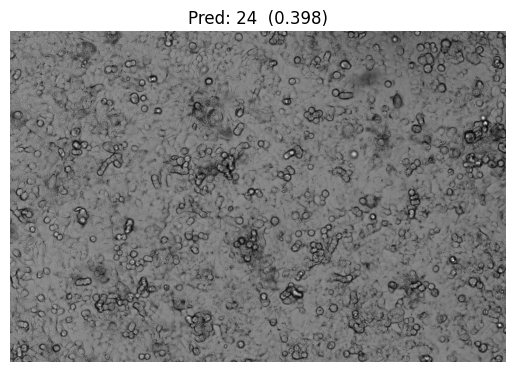

Probabilities:
24      : 0.3976
48      : 0.2285
72      : 0.0010
healthy : 0.3729


('24', 0.3976476)

In [18]:
predict_single_image("D:\cells\A549_png\\48\\TUC-20251224055455941.png")